## Load the Model
Load 8 bit Quantized Model


In [1]:
from tensorflow.keras.models import load_model
import os
from google.colab import drive

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path where the model was saved in Google Drive
model_save_dir = '/content/drive/My Drive/LeNet-5'
model_load_path = os.path.join(model_save_dir, 'Models/lenet5_mnist_model_q07.keras')

# Load the saved model
model = load_model(model_load_path)

# Print the summary of the loaded model to verify
model.summary()

print(f"LeNet-5 model loaded successfully from '{model_load_path}'.")

Mounted at /content/drive


Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,280 (520.63 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,854 (347.09 KB)

LeNet-5 model loaded successfully from '/content/drive/My Drive/LeNet-5/Models/lenet5_mnist_model_q07.keras'.


## Load MNIST Test Dataset

### Subtask:
Load the MNIST test dataset (images and labels) to be used for evaluating the accuracy of the original and quantized models.


**Reasoning**:
The subtask requires loading the MNIST test dataset, normalizing the image pixel values, and reshaping them to include a channel dimension, which is standard preprocessing for convolutional neural networks like LeNet-5. I will also one-hot encode the labels.



In [2]:
import tensorflow as tf
import numpy as np

# 1. Load the MNIST test dataset
(_, _), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Original x_test shape: {x_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

# 2. Preprocess the test images
# Normalize pixel values to the range [0, 1]
x_test = x_test.astype('float32') / 255.0

# Reshape images to add a channel dimension (for grayscale, it's 1 channel)
# LeNet-5 expects input shape (batch_size, height, width, channels)
x_test = np.expand_dims(x_test, -1)

# One-hot encode the labels
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"Processed x_test shape: {x_test.shape}")
print(f"Processed y_test shape: {y_test.shape}")
print("MNIST test dataset loaded and preprocessed successfully.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)
Processed x_test shape: (10000, 28, 28, 1)
Processed y_test shape: (10000, 10)
MNIST test dataset loaded and preprocessed successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


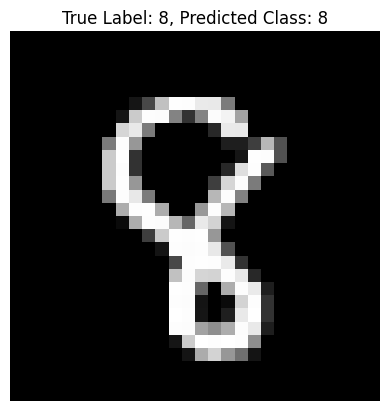

Original Image Shape: (28, 28, 1)
Image for Prediction Shape: (1, 28, 28, 1)
Prediction Probabilities: [[5.8130351e-10 2.3310433e-08 1.1593264e-08 6.5394118e-10 6.7374216e-08
  9.9238747e-08 2.0579773e-09 3.5214071e-11 9.9999893e-01 8.8899412e-07]]
True Label: 8
Predicted Class: 8


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Get a random index from the test dataset
random_index = np.random.randint(0, len(x_test))

# Get the random test image and its true label
random_image = x_test[random_index]
true_label_one_hot = y_test[random_index]
true_label = np.argmax(true_label_one_hot)

# The model expects a batch of images, so add a batch dimension
# The shape of random_image is (28, 28, 1), we need (1, 28, 28, 1)
image_for_prediction = np.expand_dims(random_image, axis=0)

# Make a prediction using the model
predictions = model.predict(image_for_prediction)
predicted_class = np.argmax(predictions)

# Display the image and prediction
plt.imshow(random_image.squeeze(), cmap='gray') # .squeeze() removes the channel dimension for display
plt.title(f"True Label: {true_label}, Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()

print(f"Original Image Shape: {random_image.shape}")
print(f"Image for Prediction Shape: {image_for_prediction.shape}")
print(f"Prediction Probabilities: {predictions}")
print(f"True Label: {true_label}")
print(f"Predicted Class: {predicted_class}")

# Define Feature Extractor for layer Dense 1
Here we will define a feature extractor for layer Dense 1 where we have 3 models:

- First, the Input Extractor Model which will have all the layers before our target layer -which here is dense1- and the output of this model will be saved as input for our target layer.

- Second, The Target layer Model which will have our target layer with input feature coming from the output of The input Extractor Model and the output of this model will be saved as output for our target layer and weights of this model will be saved as our weights.

- Third, The Remaining model which is an optional model generated to see the Final output of LeNet-5 orignal model and see whether we affected the accuracy of the model or not.

Our Target is to generate this code as abstract as possible to apply this steps for any layers in the future.

In [31]:
import tensorflow as tf

def create_feature_extractor_models(original_model, target_layer_name):
    """
    Creates three models for a given target layer:
    1. Input Extractor Model: All layers before the target layer.
    2. Target Layer Model: The target layer itself.
    3. Remaining Model: All layers after the target layer.

    Args:
        original_model (tf.keras.Model): The complete original model.
        target_layer_name (str): The name of the layer to extract.

    Returns:
        tuple: (input_extractor_model, target_layer_model, remaining_model)
    """
    # Find the target layer and its index
    target_layer = None
    target_layer_index = -1
    for i, layer in enumerate(original_model.layers):
        if layer.name == target_layer_name:
            target_layer = layer
            target_layer_index = i
    if target_layer is None:
        raise ValueError(f"Target layer '{target_layer_name}' not found in the model.")

    # 1. Create Input Extractor Model
    # This model will output the input to our target layer
    if target_layer_index == 0:
        # If target layer is the first layer, input_extractor_model is not applicable
        input_extractor_model = None
        input_to_target_layer_output = original_model.layers[0].input
    else:
        input_to_target_layer = original_model.layers[target_layer_index - 1].output
        # Ensure the model is built before accessing original_model.inputs
        if not original_model.built:
            original_model.build(input_shape=(None, 28, 28, 1)) # Assuming LeNet-5 input shape
        input_extractor_model = tf.keras.Model(inputs=original_model.inputs, outputs=input_to_target_layer,name = f"{target_layer_name}_input_extractor_model")
        input_to_target_layer_output = input_extractor_model.output

    # 2. Create Target Layer Model
    # This model takes the output of the input_extractor_model as its input
    target_layer_input_shape = target_layer.input.shape
    # Handle cases where input_shape might be (None, H, W, C) for the batch dimension
    if isinstance(target_layer_input_shape, list): # For models with multiple inputs
        # Assuming a single input for simplicity in this LeNet-5 context
        target_layer_input_shape = target_layer_input_shape[0]
    # Create a dummy input tensor with batch dimension set to None
    target_layer_input_tensor = tf.keras.Input(shape=target_layer_input_shape[1:])
    target_layer_output_tensor = target_layer(target_layer_input_tensor)
    target_layer_model = tf.keras.Model(inputs=target_layer_input_tensor, outputs=target_layer_output_tensor, name=f"{target_layer_name}_model")
    target_layer_model.set_weights(target_layer.get_weights())


    # 3. Create Remaining Model
    # This model takes the output of the target layer as its input
    if target_layer_index == len(original_model.layers) - 1:
      # If target layer is the last layer, remaining_model is not applicable
      remaining_model = None
    else:
      # Create a new input tensor for the 'remaining' part of the model
      remaining_input_tensor = tf.keras.Input(shape=target_layer.output.shape[1:])
      x = remaining_input_tensor
      for i in range(target_layer_index + 1, len(original_model.layers)):
          layer = original_model.layers[i]
          x = layer(x)
      remaining_model = tf.keras.Model(inputs=remaining_input_tensor, outputs=x, name=f"remaining_after_{target_layer_name}_model")

    return input_extractor_model, target_layer_model, remaining_model

# --- Example Usage for 'dense1' ---

target_layer_name = 'dense2'

# Assuming 'model' (the original LeNet-5) is already loaded from previous cells
# Explicitly build the model with its expected input shape
# The input shape for LeNet-5 for MNIST is (28, 28, 1)
if not model.built:
    model.build((None, 28, 28, 1)) # None for batch dimension

input_extractor_model, dense1_model, remaining_model = \
    create_feature_extractor_models(model, target_layer_name)

print(f"\n--- Models for '{target_layer_name}' ---")

if input_extractor_model:
    print("\nInput Extractor Model Summary:")
    input_extractor_model.summary()

print("\nTarget Layer Model Summary (dense1):")
dense1_model.summary()

if remaining_model:
    print("\nRemaining Model Summary:")
    remaining_model.summary()

print("\nFeature extraction models defined and instantiated for 'dense1'.")



--- Models for 'dense2' ---

Input Extractor Model Summary:


Model: "dense2_input_extractor_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,412 (130.52 KB)

 Trainable params: 33,412 (130.52 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 850 (3.32 KB)

 Trainable params: 850 (3.32 KB)

 Non-trainable params: 0 (0.00 B)


Feature extraction models defined and instantiated for 'dense1'.


Original Image Shape: (28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Dense1 input features shape: (1, 120)
Dense1 input features: [[0.         1.6220467  0.         0.         0.         0.
  0.2272347  1.8594972  5.3633456  0.         0.         1.2279015
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.7372614  0.         2.3115318
  0.         1.162121   0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.6802753  0.         0.06484953
  0.         0.         0.         3.9180455  0.         4.606882
  1.8861948  0.         0.         0.         7.7252984  0.
  0.         0.         0.         0.         0.         0.
  2.1043959  0.         0.         5.282492   2.3354006  3.2576222
  0.02352523 0.         0.         0.         0.         0.
  1.2331406  3.4338822  0.         0.         0.         0.
  0.         0.         0.         0.29427865 0.    

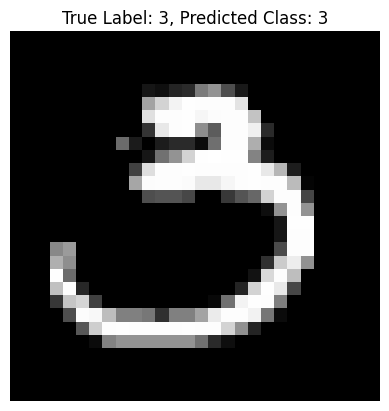

In [32]:
#-----------------------------------------------------------------------------------------------
### testing the model
input_extractor_model, dense1_model, remaining_model = \
    create_feature_extractor_models(model, target_layer_name)

# Get a random index from the test dataset
random_index = np.random.randint(0, len(x_test))

# Get the random test image and its true label
random_image = x_test[random_index]
true_label_one_hot = y_test[random_index]
true_label = np.argmax(true_label_one_hot)
print(f"Original Image Shape: {random_image.shape}")

# Add batch dimension to the image for prediction
image_for_prediction = np.expand_dims(random_image, axis=0)

dense1_input_features = input_extractor_model.predict(image_for_prediction) # Corrected line
print(f"Dense1 input features shape: {dense1_input_features.shape}")
print(f"Dense1 input features: {dense1_input_features}")

weights,bais = dense1_model.layers[1].get_weights()
print(f"Dense layer weights shape: {weights.shape}")
print(f"Dense layer weights: {weights}")
print(f"Dense layer bais shape: {bais.shape}")
print(f"Dense layer bais: {bais}")

dense1_output_features = dense1_model.predict(dense1_input_features)
print(f"Dense1 output features shape: {dense1_output_features.shape}")
print(f"Dense1 output features: {dense1_output_features}")

predictions = remaining_model.predict(dense1_output_features)
print(f"Class output shape: {predictions.shape}")
predicted_class = np.argmax(predictions)

print(f"Prediction Probabilities: {predictions}")
print(f"True Label: {true_label}")
print(f"Predicted Class: {predicted_class}")
# Display the image and prediction
plt.imshow(random_image.squeeze(), cmap='gray') # .squeeze() removes the channel dimension for display
plt.title(f"True Label: {true_label}, Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()


# input/Output Analysis
- we will run 1000 random test data
- get the input and output of one layer in 2 arrays
- then we calculate min/ max value and draw an Histrogram for it
- deduce the best presion point.

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def data_analysis(flattened_weights):
  # 1. Convert the all_flattened_weights list into a single NumPy array
  # Ensure the data type is appropriate for numerical analysis (e.g., np.float32).
  combined_weights = np.array(flattened_weights, dtype=np.float32)

  print(f"Total number of Values: {len(combined_weights)}")
  # print(f"Min value: {np.min(combined_weights):.4f}")
  print(f"Max value: {np.max(combined_weights):.4f}")
  # print(f"Mean value: {np.mean(combined_weights):.4f}")
  # print(f"Standard deviation : {np.std(combined_weights):.4f}")

  # Ratio of elements greater than 1
  one_count = (combined_weights > 1).sum()
  zero_count = (combined_weights == 0).sum()
  print(f"Ratio of number greater than 1 = {(one_count/len(combined_weights))*100:.2f}%")
  print(f"Ratio of number equal to 0 = {(zero_count/len(combined_weights))*100:.2f}%")
  # 2. Create a histogram plot for this combined array of weights.
  # Use a sufficient number of bins (e.g., 50 or 100) to clearly show the distribution.
  plt.figure(figsize=(12, 7))
  plt.hist(combined_weights, bins=100, color='teal', edgecolor='black')

  # 3. Add a title to the plot
  plt.title('Overall Distribution Across All Layers', fontsize=18)

  # 4. Label the x-axis as 'Weight Value' and the y-axis as 'Frequency'.
  plt.xlabel('Value', fontsize=14)
  plt.ylabel('Frequency', fontsize=14)
  plt.grid(axis='y', alpha=0.75)
  plt.xticks(fontsize=10)
  plt.yticks(fontsize=10)

  # 5. Display the plot.
  plt.show()


Models are Created. Starting the test data Collections
Test Data Collection is finished
------- Input features---------
Ratio of images that output features greater than one = 0.00
Total number of Values: 392000
Max value: 1.0000
Ratio of number greater than 1 = 0.00%
Ratio of number equal to 0 = 80.64%


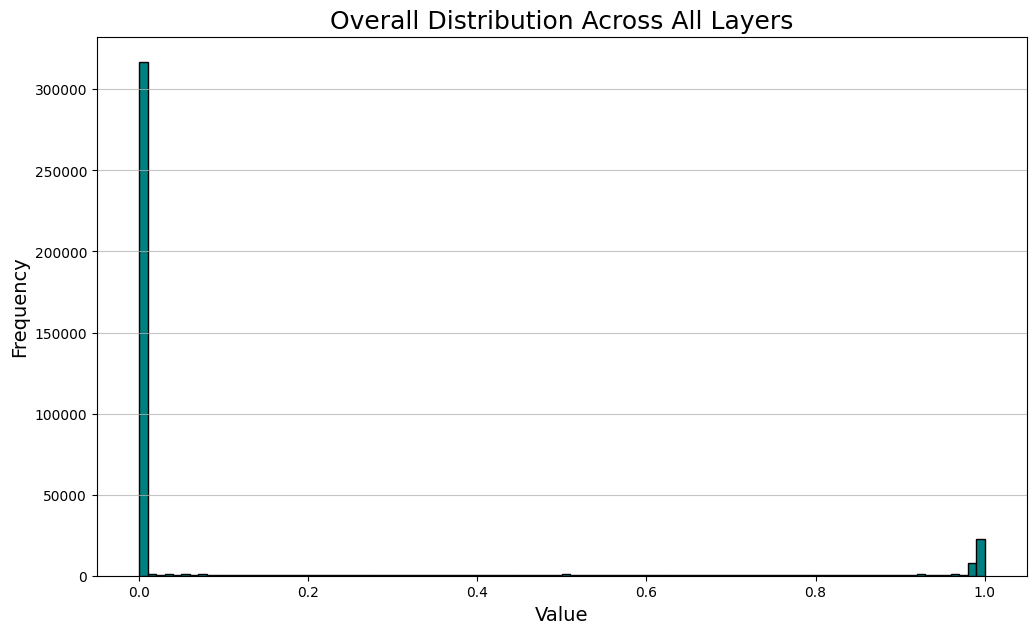

------- Conv1 features---------
Ratio of images that output features greater than one = 100.00
Total number of Values: 1728000
Max value: 2.0995
Ratio of number greater than 1 = 3.41%
Ratio of number equal to 0 = 59.85%


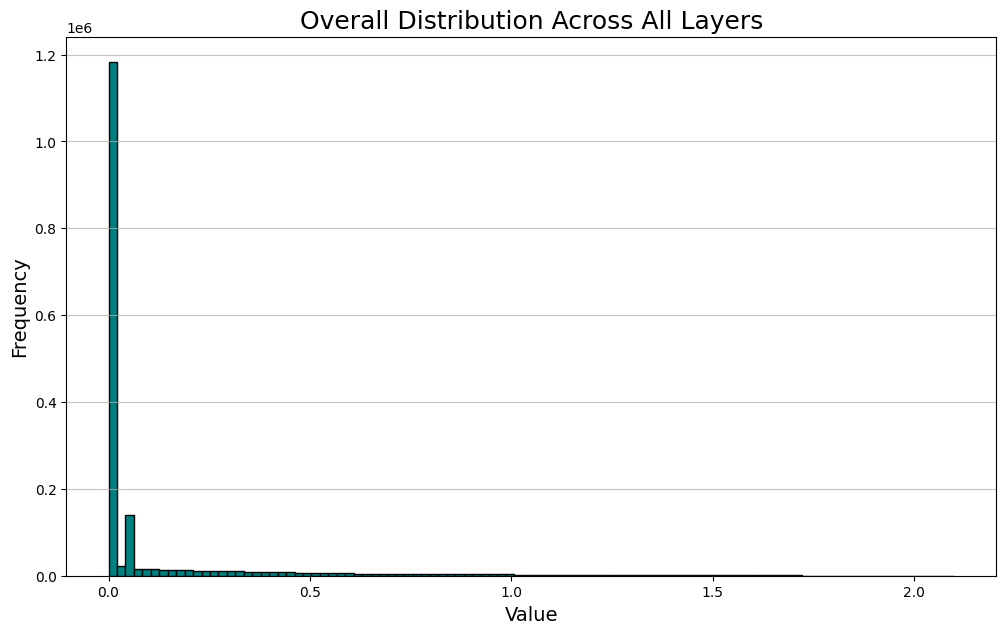

------- pool1 features---------
Ratio of images that output features greater than one = 100.00
Total number of Values: 432000
Max value: 2.0995
Ratio of number greater than 1 = 6.92%
Ratio of number equal to 0 = 48.63%


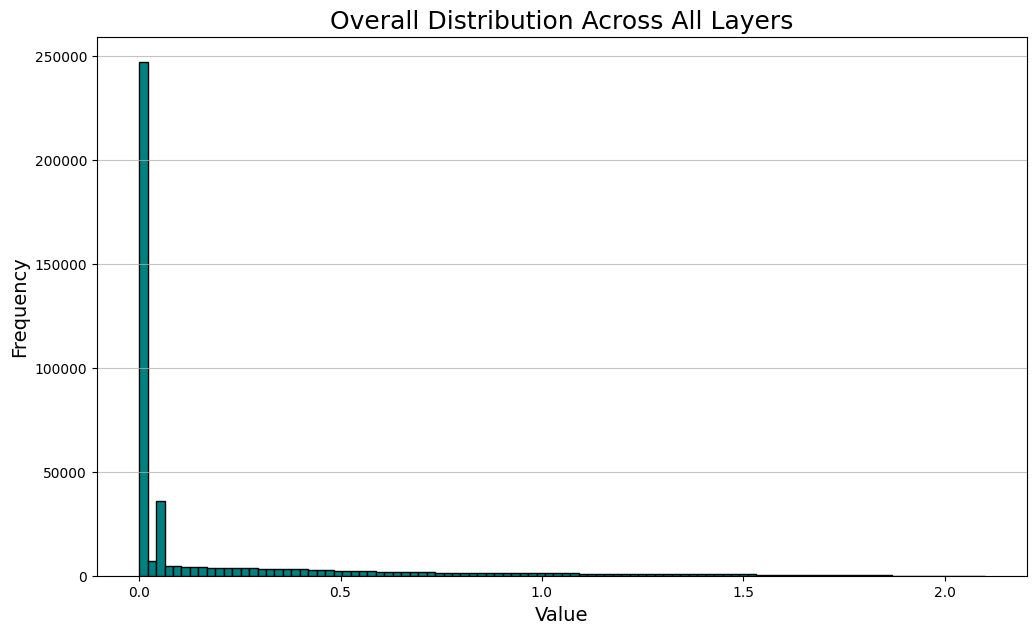

------- Conv2 features---------
Ratio of images that output features greater than one = 100.00
Total number of Values: 512000
Max value: 4.8947
Ratio of number greater than 1 = 6.20%
Ratio of number equal to 0 = 80.16%


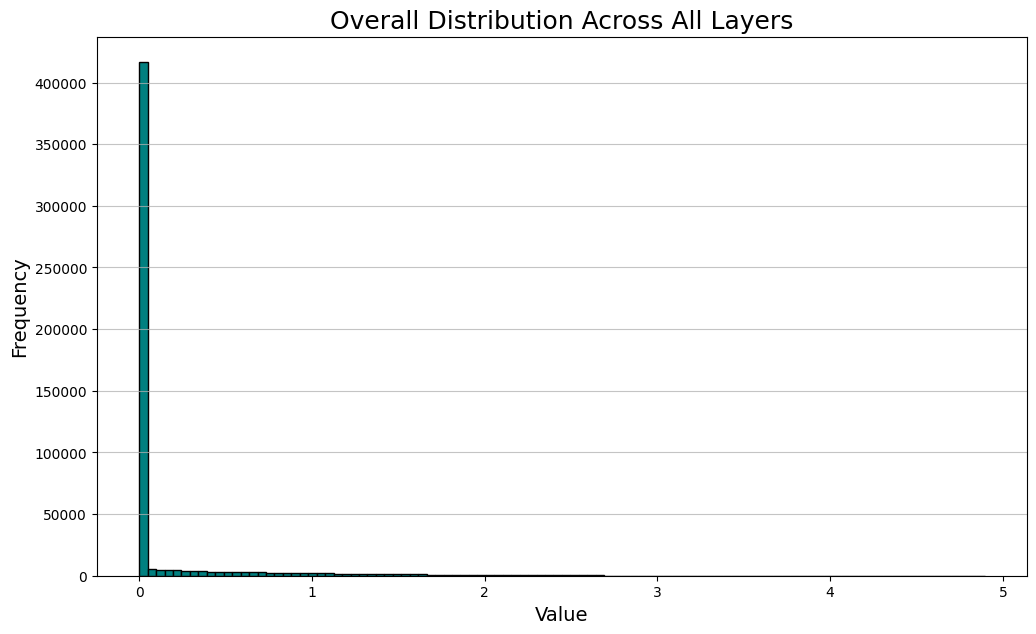

------- pool2 features---------
Ratio of images that output features greater than one = 100.00
Total number of Values: 128000
Max value: 4.8947
Ratio of number greater than 1 = 15.67%
Ratio of number equal to 0 = 59.81%


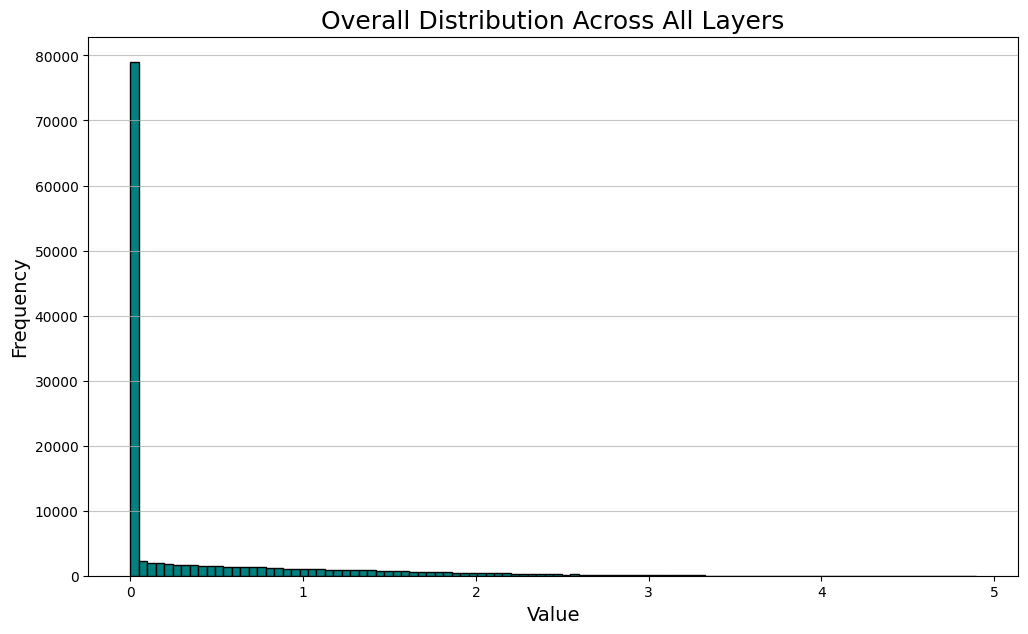

-------Dense1 output features---------
Ratio of images that output features greater than one = 100.00
Total number of Values: 60000
Max value: 8.9563
Ratio of number greater than 1 = 19.12%
Ratio of number equal to 0 = 70.71%


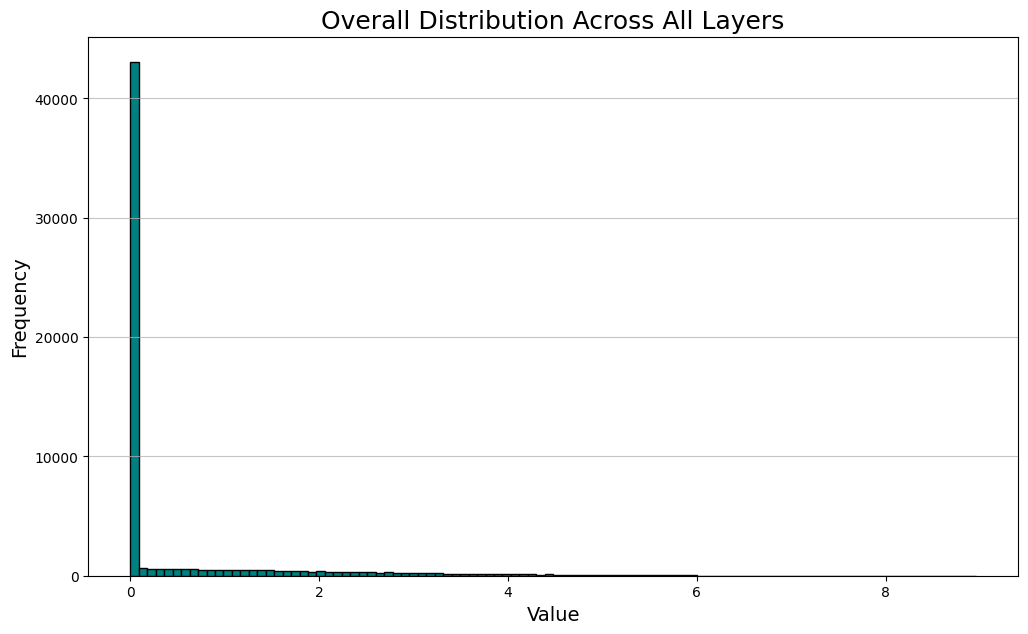

-------Dense2 output features---------
Ratio of images that output features greater than one = 100.00
Total number of Values: 42000
Max value: 14.7157
Ratio of number greater than 1 = 32.05%
Ratio of number equal to 0 = 58.89%


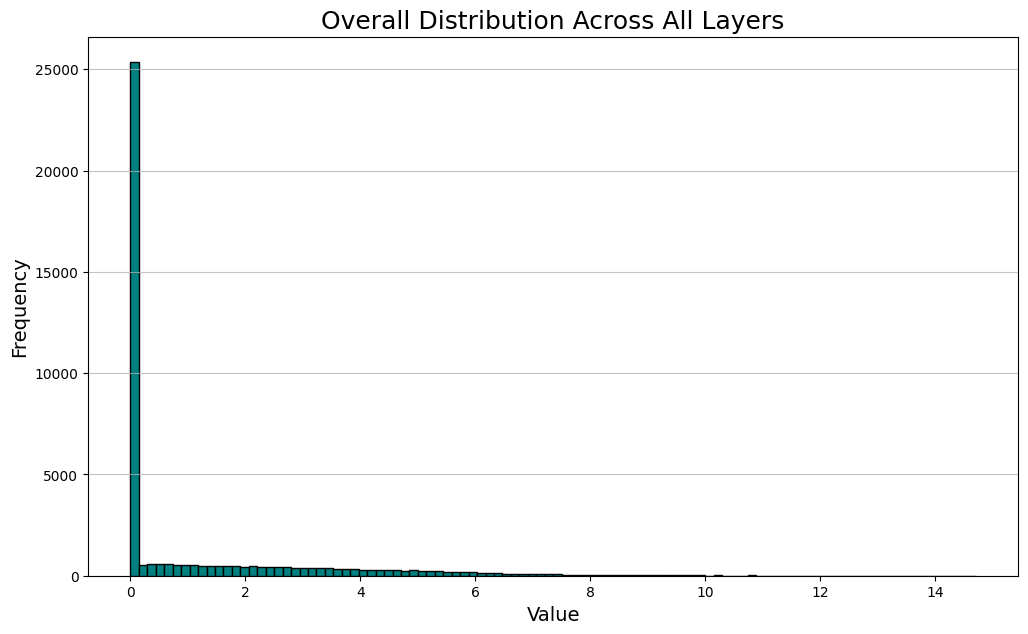

In [69]:
from matplotlib.cbook import flatten

Test_length = 500
### testing the model
conv1_model, pool1_model,_ = \
    create_feature_extractor_models(model,"pool1")

conv2_model, pool2_model,_ = \
    create_feature_extractor_models(model,"pool2")

dense_prev_model, dense1_model,_ = \
    create_feature_extractor_models(model,"dense1")

_,dense2_model,_ = \
    create_feature_extractor_models(model,"dense2")

input_val_list  = []
conv1_out_list  = []
pool1_out_list  = []
conv2_out_list  = []
pool2_out_list  = []
dense1_out_list = []
dense2_out_list = []

input_count = 0
input_count_list = []
conv1_count = 0
conv1_count_list = []
pool1_count = 0
pool1_count_list = []
conv2_count = 0
conv2_count_list = []
pool2_count = 0
pool2_count_list = []
dense1_count = 0
dense1_count_list = []
dense2_count = 0
dense2_count_list = []

print(f"Models are Created. Starting the test data Collections")
for index in range(Test_length):
  # Get a random test image and its true label
  random_index = np.random.randint(0, len(x_test))
  random_image = x_test[random_index]
  true_label_one_hot = y_test[random_index]
  true_label = np.argmax(true_label_one_hot)

  # Add batch dimension to the image for prediction
  image_for_prediction = np.expand_dims(random_image, axis=0)

  current_conv1_features  = conv1_model.predict(image_for_prediction,verbose=0)
  current_pool1_features  = pool1_model.predict(current_conv1_features,verbose=0)
  current_conv2_features  = conv2_model.predict(image_for_prediction,verbose=0)
  current_pool2_features  = pool2_model.predict(current_conv2_features,verbose=0)

  current_flatten_features  = dense_prev_model.predict(image_for_prediction,verbose=0)
  current_dense1_features   = dense1_model.predict(current_flatten_features,verbose=0)
  current_dense2_features   = dense2_model.predict(current_dense1_features,verbose=0)
  # Check on ratio of images that output features greater than one
  count = (image_for_prediction > 1).sum()
  if count > 0:
    input_count += 1
    input_count_list.append(count)

  count = (current_conv1_features > 1).sum()
  if count > 0:
    conv1_count += 1
    conv1_count_list.append(count)

  count = (current_pool1_features > 1).sum()
  if count > 0:
    pool1_count += 1
    pool1_count_list.append(count)

  count = (current_conv2_features > 1).sum()
  if count > 0:
    conv2_count += 1
    conv2_count_list.append(count)

  count = (current_pool2_features > 1).sum()
  if count > 0:
    pool2_count += 1
    pool2_count_list.append(count)

  count = (current_dense1_features > 1).sum()
  if count > 0:
    dense1_count += 1
    dense1_count_list.append(count)

  count = (current_dense2_features > 1).sum()
  if count > 0:
    dense2_count += 1
    dense2_count_list.append(count)
  # Concatenate all collected features into single NumPy arrays
  input_val_list.append(image_for_prediction)
  conv1_out_list.append(current_conv1_features)
  pool1_out_list.append(current_pool1_features)
  conv2_out_list.append(current_conv2_features)
  pool2_out_list.append(current_pool2_features)
  dense1_out_list.append(current_dense1_features)
  dense2_out_list.append(current_dense2_features)

print(f"Test Data Collection is finished")

print(f"------- Input features---------")
print(f"Ratio of images that output features greater than one = {(input_count/Test_length)*100:.2f}")
input_val_list    = np.array(input_val_list).flatten()
data_analysis(input_val_list)

print(f"------- Conv1 features---------")
print(f"Ratio of images that output features greater than one = {(conv1_count/Test_length)*100:.2f}")
conv1_out_list    = np.array(conv1_out_list).flatten()
data_analysis(conv1_out_list)

print(f"------- pool1 features---------")
print(f"Ratio of images that output features greater than one = {(pool1_count/Test_length)*100:.2f}")
pool1_out_list    = np.array(pool1_out_list).flatten()
data_analysis(pool1_out_list)

print(f"------- Conv2 features---------")
print(f"Ratio of images that output features greater than one = {(conv2_count/Test_length)*100:.2f}")
conv2_out_list    = np.array(conv2_out_list).flatten()
data_analysis(conv2_out_list)

print(f"------- pool2 features---------")
print(f"Ratio of images that output features greater than one = {(pool2_count/Test_length)*100:.2f}")
pool2_out_list    = np.array(pool2_out_list).flatten()
data_analysis(pool2_out_list)

print(f"-------Dense1 output features---------")
print(f"Ratio of images that output features greater than one = {(dense1_count/Test_length)*100:.2f}")
dense1_out_list    = np.array(dense1_out_list).flatten()
data_analysis(dense1_out_list )

print(f"-------Dense2 output features---------")
print(f"Ratio of images that output features greater than one = {(dense2_count/Test_length)*100:.2f}")
dense2_out_list    = np.array(dense2_out_list).flatten()
data_analysis(dense2_out_list )


In [126]:
model.summary()

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,280 (520.63 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 88,854 (347.09 KB)

## Notes on Input/Output Fixed Point Analysis
- Most of image/Features has zero values so to save power we can use sparse multiplication.
- No Features less than zero since we use Relu activation Function so all Feautres has unsigned Fixed point Representation.
- The Suggested Fixed Point Representation for the Features is `Q4.4 unsigned`
### Input Layer
- 8 bit input can be used to represent gray scale image.
### Conv1 Layer
> ``NOTE`` This layer implementation is hidden in our HW Architecture which means that its output features doesn't output in any RAM.
- all image generate features greater than one in this stage.
- the precentage of features greater than one is `3.41%`
- Max Feature value is approximately `2.1`.
> suggested Fixed point Representation for this layer is `Q3.8 unsigned`

### Pool1 Layer
- all image generate features greater than one in this stage.
- the precentage of features greater than one is `6.92%`
- Max Feature value is approximately `2.1`.
> suggested Fixed point Representation for this layer is `Q3.8 unsigned`

### Conv2 Layer
> ``NOTE`` This layer implementation is hidden in our HW Architecture which means that its output features doesn't output in any RAM.
- all image generate features greater than one in this stage.
- the precentage of features greater than one is `6.20%%`
- `80%` of outputs are zeros.
- Max Feature value is approximately `4.9`.
> suggested Fixed point Representation for this layer is `Q3.8 unsigned`

### Pool2 Layer
- all image generate features greater than one in this stage.
- the precentage of features greater than one is `15.67%`
- Max Feature value is approximately `4.9`.
> suggested Fixed point Representation for this layer is `Q3.8 unsigned`

### Dense1 Layer
- all image generate features greater than one in this stage.
- the precentage of features greater than one is `19.12%`
- `70%` of outputs are Zeros.
- Max Feature value is approximately `9.6`.
> suggested Fixed point Representation for this layer is `Q4.8 unsigned`

### Dense2 Layer
- all image generate features greater than one in this stage.
- the precentage of features greater than one is `32.05%`
- `59%` of outputs are Zeros.
- Max Feature value is approximately `14.8`.
> suggested Fixed point Representation for this layer is `Q4.8 unsigned`

## Output Layer
- the output is probablity between Zero and one.
- Most outputs are either near 0 or near 1.
> suggested Fixed point Representation for this layer is `Q0.8 unsigned`

# Calculating best accaracy for input/ output Features.
- Divide Model into independent Sub-models which divided by precence of RAM in HW Architecture:
  1. Conv1/Pool1 Layer.
  2. Conv2/Pool2/Flatten Layer.
  3. Dense1 Layer.
  4. Dense2 Layer.
  5. output Layer.
- Quantize the output Features in Fixed Point Representation `Q4.n unsigned` and loop on `n` from `0` to `12` before passing it to the next layer.
- the goal is to test final output accarcy aganist the original model.

In [114]:
import numpy as np

def quantize_to_q4_n(data, n):
    """
    Quantizes data into Unsigned Q4.n format.

    Args:
        data (float or np.array): The input value(s) to quantize.
        n (int): The number of fractional bits.

    Returns:
        np.array: The integer representation of the quantized value,
                  with the same shape as the input 'data'.
    """
    # Ensure data is a NumPy array for element-wise operations
    data_array = np.asarray(data)

    # Total bits = 4 (integer) + n (fractional)
    total_bits = 4 + n

    # 1. Scaling Factor
    scaling_factor = 2**n

    # 2. Scale and Round
    quantized = np.round(data_array * scaling_factor)

    # 3. Determine Boundaries
    # Unsigned min is 0. Max is (2^bits) - 1.
    lower_bound = 0
    upper_bound = (2**total_bits) - 1

    # 4. Clip (Saturation)
    quantized_clipped = np.clip(quantized, lower_bound, upper_bound)
    # 5. Scale Back
    # Divide by the scaling factor to convert back to floating-point Q0.15 quantized value
    scale_back = quantized_clipped / scaling_factor

    # Return the clipped integer representation, ensuring integer type
    return scale_back

# --- Example Usage demonstrating shape preservation ---
max_n_bits = 12
# Test with a 1D array
test_vals_1d = [12.18567926889, 9.233, 7.25]
print("--- Testing with 1D array ---")
data_to_quantize = np.array(test_vals_1d)
print(f"Original shape: {data_to_quantize.shape}, Data: {data_to_quantize}")
for n_bits in range(max_n_bits): # Test n=0, 1, 2
  q_val = quantize_to_q4_n(data_to_quantize, n=n_bits)
  print(f"  for n_bit = {n_bits}, Quantized shape: {q_val.shape}, Quantized values: {q_val}")

# Test with a 2D array
test_vals_2d = np.array([[1.5, 3.2], [0.1, 15.9]])
print("\n--- Testing with 2D array ---")
data_to_quantize = test_vals_2d
print(f"Original shape: {data_to_quantize.shape}, Data: {data_to_quantize}")
for n_bits in range(max_n_bits): # Test n=0, 1, 2
  q_val = quantize_to_q4_n(data_to_quantize, n=n_bits)
  print(f"  for n_bit = {n_bits}, Quantized shape: {q_val.shape}, Quantized values: {q_val}")

# Test with a scalar
test_vals_scalar = 5.7
print("\n--- Testing with scalar ---")
data_to_quantize = test_vals_scalar
print(f"Original shape: {np.asarray(data_to_quantize).shape}, Data: {data_to_quantize}")
for n_bits in range(max_n_bits): # Test n=0, 1, 2
  q_val = quantize_to_q4_n(data_to_quantize, n=n_bits)
  print(f"  for n_bit = {n_bits}, Quantized shape: {np.asarray(q_val).shape}, Quantized values: {q_val}")

--- Testing with 1D array ---
Original shape: (3,), Data: [12.18567927  9.233       7.25      ]
  for n_bit = 0, Quantized shape: (3,), Quantized values: [12.  9.  7.]
  for n_bit = 1, Quantized shape: (3,), Quantized values: [12.  9.  7.]
  for n_bit = 2, Quantized shape: (3,), Quantized values: [12.25  9.25  7.25]
  for n_bit = 3, Quantized shape: (3,), Quantized values: [12.125  9.25   7.25 ]
  for n_bit = 4, Quantized shape: (3,), Quantized values: [12.1875  9.25    7.25  ]
  for n_bit = 5, Quantized shape: (3,), Quantized values: [12.1875   9.21875  7.25   ]
  for n_bit = 6, Quantized shape: (3,), Quantized values: [12.1875    9.234375  7.25    ]
  for n_bit = 7, Quantized shape: (3,), Quantized values: [12.1875    9.234375  7.25    ]
  for n_bit = 8, Quantized shape: (3,), Quantized values: [12.1875    9.234375  7.25    ]
  for n_bit = 9, Quantized shape: (3,), Quantized values: [12.18554688  9.23242188  7.25      ]
  for n_bit = 10, Quantized shape: (3,), Quantized values: [12.1

In [124]:
import numpy as np

test_length = 500
# test images
test_images         = x_test[0:test_length]
true_label_one_hot  = y_test[0:test_length]
test_labels         = [np.argmax(label) for label in true_label_one_hot]
count = 0
#------------ original model ------------------
for index in range(test_length):
  # Add a batch dimension to the single image
  image_for_prediction = np.expand_dims(test_images[index], axis=0)
  predictions = model.predict(image_for_prediction, verbose=0)
  predicted_class = np.argmax(predictions)
  if(predicted_class == test_labels[index]):
    count += 1
  # print(count)
  # print(f"Prediction Probabilities: {predicted_class}")
  # print(f"True Label: {test_labels[index]}")
original_accurracy = count/test_length
print(f"Original Model Accurracy = {original_accurracy}")

Original Model Accurracy = 0.996


In [122]:

#-------------- Quantized Model ------------------
### testing the model
conv1poo1_model, conv2_model,_ = create_feature_extractor_models(model,"conv2")
_,pool2_model,_    = create_feature_extractor_models(model,"pool2")
_,flatten_mdoel,_  = create_feature_extractor_models(model,"flatten")
_,dense1_model,_   = create_feature_extractor_models(model,"dense1")
_,dense2_model,out_model = create_feature_extractor_models(model,"dense2")

n_bits = range(13)
accurracy_list = []
for n in n_bits:
  count  = 0
  for index in range(test_length):
    # Add a batch dimension to the single image
    image_for_prediction = np.expand_dims(test_images[index], axis=0)

    Feature_Map_1 = conv1poo1_model.predict(image_for_prediction, verbose=0)
    Feature_Map_1 = quantize_to_q4_n(Feature_Map_1, n=n)

    connect_FM_1  = conv2_model.predict(Feature_Map_1, verbose=0)
    Feature_Map_2 = pool2_model.predict(connect_FM_1, verbose=0)
    Feature_Map_2 = quantize_to_q4_n(Feature_Map_2, n=n)

    connect_FM_2  = flatten_mdoel.predict(Feature_Map_2, verbose=0)
    Feature_Map_3 = dense1_model.predict(connect_FM_2, verbose=0)
    Feature_Map_3 = quantize_to_q4_n(Feature_Map_3, n=n)

    Feature_Map_4  = dense2_model.predict(Feature_Map_3, verbose=0)
    Feature_Map_4  = quantize_to_q4_n(Feature_Map_4, n=n)

    predictions = out_model.predict(Feature_Map_4, verbose=0)
    predicted_class = np.argmax(predictions)
    if(predicted_class == test_labels[index]):
      count += 1
  accurracy = count/test_length
  accurracy_list.append(accurracy)
  print(f"Quatized Model for Q4.{n} Accurracy = {accurracy}")

Quatized Model for Q4.0 Accurracy = 0.99
Quatized Model for Q4.1 Accurracy = 0.99
Quatized Model for Q4.2 Accurracy = 0.992
Quatized Model for Q4.3 Accurracy = 0.994
Quatized Model for Q4.4 Accurracy = 0.996
Quatized Model for Q4.5 Accurracy = 0.994
Quatized Model for Q4.6 Accurracy = 0.996
Quatized Model for Q4.7 Accurracy = 0.996
Quatized Model for Q4.8 Accurracy = 0.996
Quatized Model for Q4.9 Accurracy = 0.996
Quatized Model for Q4.10 Accurracy = 0.996
Quatized Model for Q4.11 Accurracy = 0.996
Quatized Model for Q4.12 Accurracy = 0.996


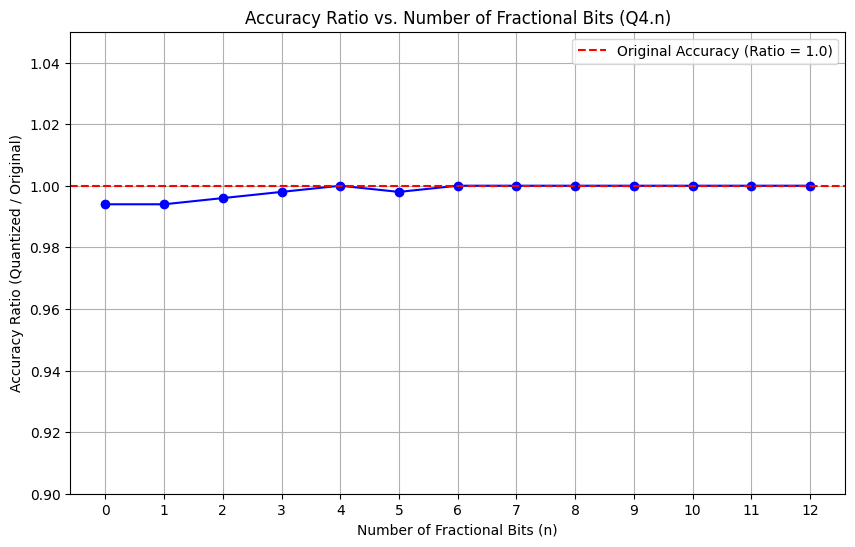

Accuracy Ratios: [0.9939759036144579, 0.9939759036144579, 0.9959839357429718, 0.9979919678714859, 1.0, 0.9979919678714859, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


In [125]:
import matplotlib.pyplot as plt

# Calculate the ratio of quantized accuracy to original accuracy
accuracy_ratio = [acc / original_accurracy for acc in accurracy_list]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(n_bits, accuracy_ratio, marker='o', linestyle='-', color='b')
plt.title('Accuracy Ratio vs. Number of Fractional Bits (Q4.n)')
plt.xlabel('Number of Fractional Bits (n)')
plt.ylabel('Accuracy Ratio (Quantized / Original)')
plt.grid(True)
plt.xticks(n_bits) # Ensure all n values are shown on x-axis
plt.ylim(0.9, 1.05) # Adjust y-axis to focus on relevant range
plt.axhline(y=1.0, color='r', linestyle='--', label='Original Accuracy (Ratio = 1.0)') # Line for original accuracy
plt.legend()
plt.show()

print(f"Accuracy Ratios: {accuracy_ratio}")

# Weights Extraction
Needed Functions
1. Quanitize the inputs and outputs to `Q0.7` signed.
2. Flatten the Weights and Baises by Hand.
3. Turn a Vector into .csv and .mem files.

In [25]:
import numpy as np

def quantize_q07(value):
    """Quantizes a floating-point number to Q0.7 fixed-point representation.
    (1 sign bit, 0 integer bits, 7 fractional bits, total 8 bits)
    Representable range: [-1.0, ~0.992]
    """
    # Scaling factor for Q0.7 (2^7)
    scale_factor = 2**7

    # Multiply by scaling factor and round to the nearest integer
    scaled_value = np.round(value * scale_factor)

    # Clamp the integer result to the valid range for a signed 8-bit integer (-128 to 127)
    clamped_value = np.clip(scaled_value, -128, 127)

    # apply the signed Q0.7
    if scaled_value < 0:
        quantized_value = np.uint8(clamped_value + 256)
    else:
        quantized_value = np.uint8(clamped_value)

    return quantized_value

sample_values_q07 = [0.5,-0.5, 0.25,-0.25, 0.99, -0.99, 1.2, -1.2, 0.001, -0.001]
for value in sample_values_q07:
  q_value = quantize_q07(value)
  print(f"value = {value} -> quanitzed uint8 value = {q_value}")


value = 0.5 -> quanitzed uint8 value = 64
value = -0.5 -> quanitzed uint8 value = 192
value = 0.25 -> quanitzed uint8 value = 32
value = -0.25 -> quanitzed uint8 value = 224
value = 0.99 -> quanitzed uint8 value = 127
value = -0.99 -> quanitzed uint8 value = 129
value = 1.2 -> quanitzed uint8 value = 127
value = -1.2 -> quanitzed uint8 value = 128
value = 0.001 -> quanitzed uint8 value = 0
value = -0.001 -> quanitzed uint8 value = 0


In [ ]:
import numpy as np

def quantize_q07(value):
    """Quantizes a floating-point number to Q0.7 fixed-point representation.
    (1 sign bit, 0 integer bits, 7 fractional bits, total 8 bits)
    Representable range: [-1.0, ~0.992]
    """
    # Scaling factor for Q0.7 (2^7)
    scale_factor = 2**7

    # Multiply by scaling factor and round to the nearest integer
    scaled_value = np.round(value * scale_factor)

    # Clamp the integer result to the valid range for a signed 8-bit integer (-128 to 127)
    clamped_value = np.clip(scaled_value, -128, 127)

    # Divide by the scaling factor to convert back to floating-point Q0.7 quantized value
    quantized_value = clamped_value / scale_factor

    return quantized_value

def get_q07_int(value):
    """Converts a floating-point number or NumPy array (assumed to be within Q0.7 range)
    to its signed 8-bit integer representation."""
    scale_factor = 2**7
    scaled_value = np.round(value * scale_factor)
    clamped_value = np.clip(scaled_value, -128, 127)
    return clamped_value.astype(int)

def quantize_q015(value):
    """Quantizes a floating-point number to Q0.15 fixed-point representation.
    (1 sign bit, 0 integer bits, 15 fractional bits, total 16 bits)
    Representable range: [-1.0, ~0.999969]
    """
    # Scaling factor for Q0.15 (2^15)
    scale_factor = 2**15

    # Multiply by scaling factor and round to the nearest integer
    scaled_value = np.round(value * scale_factor)

    # Clamp the integer result to the valid range for a signed 16-bit integer (-32768 to 32767)
    clamped_value = np.clip(scaled_value, -32768, 32767)

    # Divide by the scaling factor to convert back to floating-point Q0.15 quantized value
    quantized_value = clamped_value / scale_factor

    return quantized_value

def get_q015_int(value):
    """Converts a floating-point number or NumPy array (assumed to be within Q0.15 range)
    to its signed 16-bit integer representation."""
    scale_factor = 2**15
    scaled_value = np.round(value * scale_factor)
    clamped_value = np.clip(scaled_value, -32768, 32767)
    return clamped_value.astype(int)

# --- Test the functions ---
print("Testing Q0.7 quantization:")
sample_values_q07 = [0.5, -0.25, 0.99, -0.99, 1.2, -1.2, 0.001, -0.001]
for val in sample_values_q07:
    quantized_float_val = quantize_q07(val)
    int_val = get_q07_int(val)
    uint8_val = np.uint8(int_val + 128)
    print(f"  Original: {val:.4f}, Quantized Q0.7 (float): {quantized_float_val:.4f}, Int Q0.7: {int_val}, Uint8 Q0.7: {uint8_val}")

print("\nTesting Q0.15 quantization:")
sample_values_q015 = [0.5, -0.25, 0.999, -0.999, 1.2, -1.2, 0.00001, -0.00001]
for val in sample_values_q015:
    quantized_float_val = quantize_q015(val)
    int_val = get_q015_int(val)
    uint16_val = np.uint16(int_val + 32768)
    print(f"  Original: {val:.6f}, Quantized Q0.15 (float): {quantized_float_val:.6f}, Int Q0.15: {int_val}, Uint16 Q0.15: {uint16_val}")

print("\nQuantization functions defined and tested successfully.")

Testing Q0.7 quantization:
  Original: 0.5000, Quantized Q0.7 (float): 0.5000, Int Q0.7: 64, Uint8 Q0.7: 192
  Original: -0.2500, Quantized Q0.7 (float): -0.2500, Int Q0.7: -32, Uint8 Q0.7: 96
  Original: 0.9900, Quantized Q0.7 (float): 0.9922, Int Q0.7: 127, Uint8 Q0.7: 255
  Original: -0.9900, Quantized Q0.7 (float): -0.9922, Int Q0.7: -127, Uint8 Q0.7: 1
  Original: 1.2000, Quantized Q0.7 (float): 0.9922, Int Q0.7: 127, Uint8 Q0.7: 255
  Original: -1.2000, Quantized Q0.7 (float): -1.0000, Int Q0.7: -128, Uint8 Q0.7: 0
  Original: 0.0010, Quantized Q0.7 (float): 0.0000, Int Q0.7: 0, Uint8 Q0.7: 128
  Original: -0.0010, Quantized Q0.7 (float): -0.0000, Int Q0.7: 0, Uint8 Q0.7: 128

Testing Q0.15 quantization:
  Original: 0.500000, Quantized Q0.15 (float): 0.500000, Int Q0.15: 16384, Uint16 Q0.15: 49152
  Original: -0.250000, Quantized Q0.15 (float): -0.250000, Int Q0.15: -8192, Uint16 Q0.15: 24576
  Original: 0.999000, Quantized Q0.15 (float): 0.998993, Int Q0.15: 32735, Uint16 Q0.15: